# AlexNet Cat vs Dog Classification

This notebook implements AlexNet from scratch using PyTorch for binary classification of cats and dogs.

## Overview
1. Dataset Download and Preparation
2. Data Preprocessing and DataLoaders
3. AlexNet Architecture Implementation
4. Training Loop
5. Model Evaluation and Metrics

In [12]:
# Import necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import zipfile
import requests
from tqdm import tqdm
import time

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

Using device: cuda


In [13]:
# Download and extract the dataset
def download_dataset():
    url = 'https://www.kaggle.com/api/v1/datasets/download/bhavikjikadara/dog-and-cat-classification-dataset'
    filename = 'dog-and-cat-classification-dataset.zip'

    # Check if dataset already exists
    if os.path.exists('./dataset'):
        print("Dataset already exists!")
        return

    print("Downloading dataset...")
    try:
        # For Kaggle API, you might need to set up API credentials
        # Alternative: Manual download or use a different approach
        os.system('curl -L -o ./dog-and-cat-classification-dataset.zip https://www.kaggle.com/api/v1/datasets/download/bhavikjikadara/dog-and-cat-classification-dataset')

        # Extract the dataset
        print("Extracting dataset...")
        with zipfile.ZipFile(filename, 'r') as zip_ref:
            zip_ref.extractall('./dataset')

        # Remove the zip file
        os.remove(filename)
        print("Dataset downloaded and extracted successfully!")

    except Exception as e:
        print(f"Error downloading dataset: {e}")
        print("Please manually download the dataset and place it in the './dataset' folder")

# Download the dataset
download_dataset()

Dataset already exists!


In [14]:
# Explore dataset structure
def explore_dataset():
    dataset_path = './dataset/PetImages'

    # Check if dataset exists
    if not os.path.exists(dataset_path):
        print("Dataset not found! Please ensure the dataset is downloaded.")
        return

    # List contents
    print("Dataset structure:")
    for root, dirs, files in os.walk(dataset_path):
        level = root.replace(dataset_path, '').count(os.sep)
        indent = ' ' * 2 * level
        print(f"{indent}{os.path.basename(root)}/")
        subindent = ' ' * 2 * (level + 1)
        for file in files[:5]:  # Show first 5 files
            print(f"{subindent}{file}")
        if len(files) > 5:
            print(f"{subindent}... and {len(files) - 5} more files")

explore_dataset()

Dataset structure:
PetImages/
  Dog/
    3591.jpg
    12437.jpg
    12436.jpg
    3686.jpg
    10686.jpg
    ... and 12494 more files
  Cat/
    3591.jpg
    12437.jpg
    12436.jpg
    3686.jpg
    10686.jpg
    ... and 12494 more files


In [ ]:
# Define transforms for data preprocessing
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create dataset from PetImages folder structure
from torch.utils.data import random_split

try:
    # Load the complete dataset
    full_dataset = ImageFolder('./dataset/PetImages', transform=train_transform)
    
    print(f"Total samples: {len(full_dataset)}")
    print(f"Classes: {full_dataset.classes}")
    print(f"Class to index mapping: {full_dataset.class_to_idx}")
    
    # Split dataset into train and test (80-20 split)
    train_size = int(0.8 * len(full_dataset))
    test_size = len(full_dataset) - train_size
    
    train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])
    
    # Apply validation transforms to test dataset
    # Note: We need to create a wrapper to apply different transforms
    class TransformDataset(torch.utils.data.Dataset):
        def __init__(self, subset, transform=None):
            self.subset = subset
            self.transform = transform
            
        def __getitem__(self, index):
            x, y = self.subset[index]
            if self.transform:
                # Get the original image without transforms
                img_path = self.subset.dataset.imgs[self.subset.indices[index]][0]
                img = Image.open(img_path).convert('RGB')
                x = self.transform(img)
            return x, y
            
        def __len__(self):
            return len(self.subset)
    
    # Create datasets with appropriate transforms
    test_dataset = TransformDataset(test_dataset, val_transform)
    
    print(f"Training samples: {len(train_dataset)}")
    print(f"Test samples: {len(test_dataset)}")
    
except Exception as e:
    print(f"Error loading dataset: {e}")
    print("Please check the dataset structure. Expected structure:")
    print("./dataset/PetImages/Cat/")
    print("./dataset/PetImages/Dog/")

Training samples: 24998
Test samples: 24998
Classes: ['Cat', 'Dog']


Number of training batches: 782
Number of test batches: 782


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


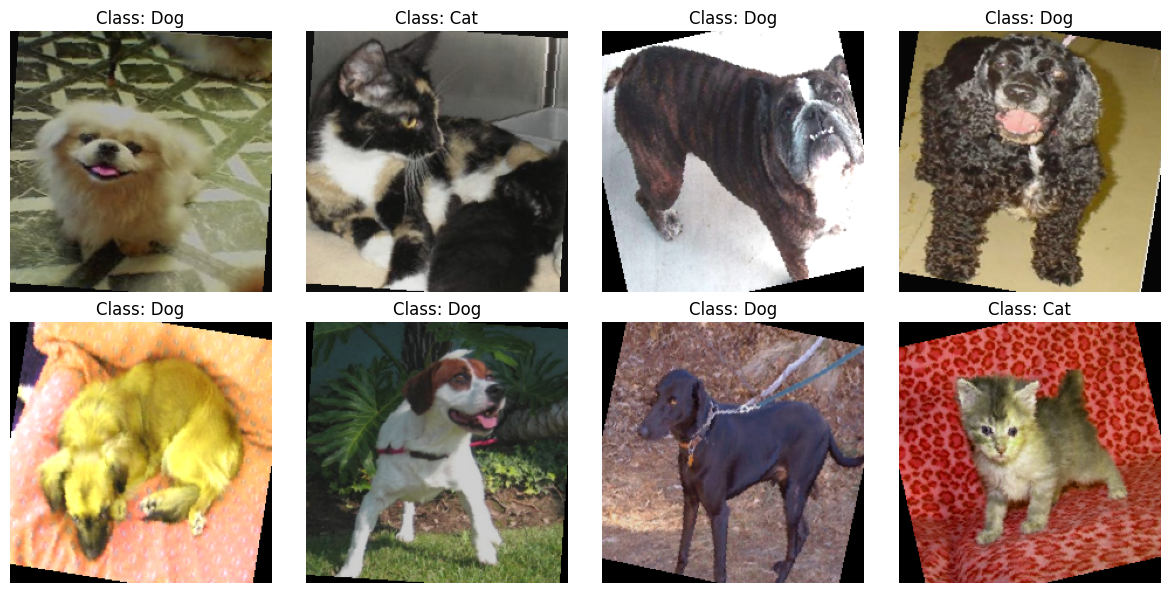

In [ ]:
# Create data loaders
batch_size = 32
num_workers = 4

train_loader = DataLoader(train_dataset,
                         batch_size=batch_size,
                         shuffle=True,
                         num_workers=num_workers,
                         pin_memory=True)

test_loader = DataLoader(test_dataset,
                        batch_size=batch_size,
                        shuffle=False,
                        num_workers=num_workers,
                        pin_memory=True)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of test batches: {len(test_loader)}")

# Visualize some samples
def visualize_samples():
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))

    # Get a batch of training data
    data_iter = iter(train_loader)
    images, labels = next(data_iter)

    # Denormalize for visualization
    mean = torch.tensor([0.485, 0.456, 0.406])
    std = torch.tensor([0.229, 0.224, 0.225])
    
    # Get class names from the original dataset
    class_names = full_dataset.classes

    for i in range(8):
        row = i // 4
        col = i % 4

        # Denormalize
        img = images[i] * std[:, None, None] + mean[:, None, None]
        img = torch.clamp(img, 0, 1)

        axes[row, col].imshow(img.permute(1, 2, 0))
        axes[row, col].set_title(f'Class: {class_names[labels[i]]}')
        axes[row, col].axis('off')

    plt.tight_layout()
    plt.show()

visualize_samples()

In [17]:
# AlexNet Implementation from scratch
class AlexNet(nn.Module):
    def __init__(self, num_classes=2):
        super(AlexNet, self).__init__()

        # Feature extraction layers
        self.features = nn.Sequential(
            # First convolutional layer
            nn.Conv2d(3, 64, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),

            # Second convolutional layer
            nn.Conv2d(64, 192, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),

            # Third convolutional layer
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            # Fourth convolutional layer
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            # Fifth convolutional layer
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),
        )

        # Adaptive pooling to handle different input sizes
        self.avgpool = nn.AdaptiveAvgPool2d((6, 6))

        # Classifier layers
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.5),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes),
        )

        # Initialize weights
        self._initialize_weights()

    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                nn.init.constant_(m.bias, 0)

# Create model instance
model = AlexNet(num_classes=2).to(device)

# Print model summary
print("AlexNet Model Architecture:")
print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

AlexNet Model Architecture:
AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out

In [18]:
# Training and validation functions
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(train_loader, desc='Training')
    for batch_idx, (data, target) in enumerate(pbar):
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(output.data, 1)
        total += target.size(0)
        correct += (predicted == target).sum().item()

        # Update progress bar
        pbar.set_postfix({
            'Loss': f'{running_loss/(batch_idx+1):.4f}',
            'Acc': f'{100.*correct/total:.2f}%'
        })

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct / total

    return epoch_loss, epoch_acc

def validate_epoch(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        pbar = tqdm(val_loader, desc='Validation')
        for batch_idx, (data, target) in enumerate(pbar):
            data, target = data.to(device), target.to(device)

            output = model(data)
            loss = criterion(output, target)

            running_loss += loss.item()
            _, predicted = torch.max(output.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()

            # Update progress bar
            pbar.set_postfix({
                'Loss': f'{running_loss/(batch_idx+1):.4f}',
                'Acc': f'{100.*correct/total:.2f}%'
            })

    epoch_loss = running_loss / len(val_loader)
    epoch_acc = 100. * correct / total

    return epoch_loss, epoch_acc

In [ ]:
# Training setup
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

num_epochs = 20
best_acc = 0.0
best_model_state = None

# Lists to store training history
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

print("Starting training...")
start_time = time.time()

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print("-" * 50)

    # Training phase
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)

    # Validation phase
    val_loss, val_acc = validate_epoch(model, test_loader, criterion, device)

    # Step the scheduler
    scheduler.step()

    # Store metrics
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    # Save best model
    if val_acc > best_acc:
        best_acc = val_acc
        best_model_state = model.state_dict().copy()
        print(f"New best validation accuracy: {best_acc:.2f}%")

    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
    print(f"Learning Rate: {optimizer.param_groups[0]['lr']:.6f}")

total_time = time.time() - start_time
print(f"\nTraining completed in {total_time//60:.0f}m {total_time%60:.0f}s")
print(f"Best validation accuracy: {best_acc:.2f}%")

# Load best model
model.load_state_dict(best_model_state)

# Save the trained model
torch.save({
    'model_state_dict': best_model_state,
    'optimizer_state_dict': optimizer.state_dict(),
    'best_acc': best_acc,
    'train_losses': train_losses,
    'train_accuracies': train_accuracies,
    'val_losses': val_losses,
    'val_accuracies': val_accuracies,
}, 'alexnet_cat_dog_classifier.pth')

print("Model saved as 'alexnet_cat_dog_classifier.pth'")

Starting training...

Epoch 1/20
--------------------------------------------------


Training:  36%|███▋      | 284/782 [01:22<01:55,  4.30it/s, Loss=0.8074, Acc=49.51%]/usr/local/lib/python3.11/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))
Training:  74%|███████▎  | 575/782 [02:45<00:48,  4.24it/s, Loss=0.7499, Acc=49.40%]

In [ ]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot loss
ax1.plot(range(1, num_epochs+1), train_losses, 'b-', label='Training Loss')
ax1.plot(range(1, num_epochs+1), val_losses, 'r-', label='Validation Loss')
ax1.set_title('Model Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Plot accuracy
ax2.plot(range(1, num_epochs+1), train_accuracies, 'b-', label='Training Accuracy')
ax2.plot(range(1, num_epochs+1), val_accuracies, 'r-', label='Validation Accuracy')
ax2.set_title('Model Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# Print final statistics
print(f"Final Training Accuracy: {train_accuracies[-1]:.2f}%")
print(f"Final Validation Accuracy: {val_accuracies[-1]:.2f}%")
print(f"Best Validation Accuracy: {best_acc:.2f}%")

In [ ]:
# Generate detailed classification metrics
def evaluate_model(model, test_loader, device, class_names):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for data, target in tqdm(test_loader, desc='Evaluating'):
            data, target = data.to(device), target.to(device)
            output = model(data)

            # Get probabilities
            probs = F.softmax(output, dim=1)
            all_probs.extend(probs.cpu().numpy())

            # Get predictions
            _, predicted = torch.max(output, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(target.cpu().numpy())

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

# Evaluate the model
class_names = full_dataset.classes  # Use class names from the original dataset
y_true, y_pred, y_probs = evaluate_model(model, test_loader, device, class_names)

# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Calculate per-class accuracy
for i, class_name in enumerate(class_names):
    class_mask = (y_true == i)
    class_acc = accuracy_score(y_true[class_mask], y_pred[class_mask])
    print(f"{class_name} accuracy: {class_acc:.4f} ({class_acc*100:.2f}%)")

In [ ]:
# Visualize some predictions
def visualize_predictions(model, test_loader, device, class_names, num_images=8):
    model.eval()

    # Get a batch of test data
    data_iter = iter(test_loader)
    images, labels = next(data_iter)
    images, labels = images.to(device), labels.to(device)

    with torch.no_grad():
        outputs = model(images)
        probabilities = F.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)

    # Denormalization for visualization
    mean = torch.tensor([0.485, 0.456, 0.406]).to(device)
    std = torch.tensor([0.229, 0.224, 0.225]).to(device)

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))

    for i in range(num_images):
        row = i // 4
        col = i % 4

        # Denormalize image
        img = images[i] * std[:, None, None] + mean[:, None, None]
        img = torch.clamp(img, 0, 1)

        # Move to CPU for visualization
        img = img.cpu()
        true_label = labels[i].cpu().item()
        pred_label = predicted[i].cpu().item()
        confidence = probabilities[i][pred_label].cpu().item()

        # Plot image
        axes[row, col].imshow(img.permute(1, 2, 0))

        # Set title with prediction info
        color = 'green' if true_label == pred_label else 'red'
        title = f'True: {class_names[true_label]}\nPred: {class_names[pred_label]}\nConf: {confidence:.3f}'
        axes[row, col].set_title(title, color=color, fontsize=10)
        axes[row, col].axis('off')

    plt.tight_layout()
    plt.suptitle('Model Predictions (Green=Correct, Red=Incorrect)', y=1.02, fontsize=14)
    plt.show()

# Visualize predictions
visualize_predictions(model, test_loader, device, class_names)

# Find and visualize misclassified examples
def find_misclassified(model, test_loader, device, class_names, num_examples=4):
    model.eval()
    misclassified = []

    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            _, predicted = torch.max(output, 1)

            # Find misclassified examples
            wrong_mask = (predicted != target)
            if wrong_mask.any():
                wrong_indices = torch.where(wrong_mask)[0]
                for idx in wrong_indices:
                    if len(misclassified) < num_examples:
                        probs = F.softmax(output[idx], dim=0)
                        misclassified.append({
                            'image': data[idx],
                            'true_label': target[idx].item(),
                            'pred_label': predicted[idx].item(),
                            'confidence': probs[predicted[idx]].item()
                        })

            if len(misclassified) >= num_examples:
                break

    # Visualize misclassified examples
    if misclassified:
        fig, axes = plt.subplots(1, len(misclassified), figsize=(4*len(misclassified), 4))
        if len(misclassified) == 1:
            axes = [axes]

        mean = torch.tensor([0.485, 0.456, 0.406]).to(device)
        std = torch.tensor([0.229, 0.224, 0.225]).to(device)

        for i, example in enumerate(misclassified):
            # Denormalize image
            img = example['image'] * std[:, None, None] + mean[:, None, None]
            img = torch.clamp(img, 0, 1).cpu()

            axes[i].imshow(img.permute(1, 2, 0))
            title = f"True: {class_names[example['true_label']]}\nPred: {class_names[example['pred_label']]}\nConf: {example['confidence']:.3f}"
            axes[i].set_title(title, color='red')
            axes[i].axis('off')

        plt.suptitle('Misclassified Examples', fontsize=16)
        plt.tight_layout()
        plt.show()

find_misclassified(model, test_loader, device, class_names)

In [ ]:
# Final model summary and results
print("=" * 60)
print("ALEXNET CAT VS DOG CLASSIFICATION - FINAL RESULTS")
print("=" * 60)

print(f"\n📊 DATASET STATISTICS:")
print(f"   Total samples: {len(full_dataset):,}")
print(f"   Training samples: {len(train_dataset):,}")
print(f"   Test samples: {len(test_dataset):,}")
print(f"   Classes: {full_dataset.classes}")
print(f"   Train/Test split: 80/20")

print(f"\n🏗️ MODEL ARCHITECTURE:")
print(f"   Model: AlexNet (implemented from scratch)")
print(f"   Total parameters: {total_params:,}")
print(f"   Input size: 224x224x3")
print(f"   Output classes: 2 (Cat, Dog)")

print(f"\n🚀 TRAINING CONFIGURATION:")
print(f"   Epochs: {num_epochs}")
print(f"   Batch size: {batch_size}")
print(f"   Optimizer: Adam (lr=0.001, weight_decay=1e-4)")
print(f"   Loss function: CrossEntropyLoss")
print(f"   Device: {device}")

print(f"\n📈 TRAINING RESULTS:")
print(f"   Best validation accuracy: {best_acc:.2f}%")
print(f"   Final training accuracy: {train_accuracies[-1]:.2f}%")
print(f"   Final validation accuracy: {val_accuracies[-1]:.2f}%")
print(f"   Training time: {total_time//60:.0f}m {total_time%60:.0f}s")

print(f"\n🎯 TEST RESULTS:")
print(f"   Test accuracy: {accuracy*100:.2f}%")
print(f"   Model saved as: alexnet_cat_dog_classifier.pth")

print(f"\n🔧 DATA AUGMENTATION:")
print(f"   ✓ Random crop (224x224)")
print(f"   ✓ Random horizontal flip")
print(f"   ✓ Random rotation (±15°)")
print(f"   ✓ Color jittering")
print(f"   ✓ Normalization (ImageNet stats)")

print(f"\n📁 DATASET STRUCTURE:")
print(f"   ✓ Source: PetImages/Cat and PetImages/Dog")
print(f"   ✓ Automatic train/test split (80/20)")
print(f"   ✓ Random split with reproducible results")

print("\n" + "=" * 60)
print("Training completed successfully! 🎉")
print("=" * 60)